## 1. What this notebook computes

The Kohn-Sham states of dirac16complex in the Revision record are **instantaneous**
states: at each slice $a_{4,0}$ of the history $a_4 = A H x_4$ the solver finds the
ground state of the Hamiltonian of that one instant. The record measures how good
this picture is with the adiabaticity measure $Q$ and finds $Q_{max} \le 0.0935$ at
the record's rate $A = 1$. Behind this number lies one of the OPEN problems of this
chapter, the time-dependent problem: **how fast would the three extra times $x_5$,
$x_6$, $x_7$ have to deflate before the instantaneous picture breaks down, and what
happens then?** This notebook makes that estimate in six steps:

- it reads $Q_{max}$ of all 75 ground states of the record, shows why $Q$ grows
  exactly in proportion to the rate $A$, and computes the naive breakdown rate
  $1/Q_{max}$ of every state;
- it solves again, with the Rust solver's shooting method written in vectorised
  Python, the Fermi-shell sectors of the free states $N = 136$ and $N = 688$ at the
  five slices and reproduces the record's $Q_{max}$, energy difference and matrix
  element;
- with the exact rescaling identity it collapses every slice and every shell onto
  ONE curve: $Q/A$ against the redshifted momentum $q = k e^{-a_{4,0}}$;
- it measures the jumps across the gap into the negative-energy branch, which the
  record's filling convention leaves out;
- it solves the exact time evolution of one sector of the free field (where the
  evolution equation is exact) in a basis of 20 instantaneous levels, for rates from
  $A = 0.25$ to $A = 251$, and compares it with the first-order estimate and with the
  sudden limit;
- it collects the breakdown estimates in one table.

It draws eight figures and needs no Rust. Units: $H = m = 1$, as in the record.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 22a (When does the instantaneous Kohn-Sham picture break down) is the file
`Revision/textbook/notebooks/22a_adiabatic_breakdown.ipynb` of the repository
Dirac_claude. It estimates how fast the three extra times would have to deflate before
the instantaneous Kohn-Sham states of dirac16complex stop describing the gas: it reads
the adiabaticity measure Q of the 75 recorded ground states and shows that Q grows
exactly in proportion to the rate, reproduces Q of the free Fermi-shell sectors with the
solver's shooting method, collapses every slice and shell onto one curve with the exact
rescaling identity, measures the jumps into the negative-energy branch, and solves the
exact time evolution of the free Fermi-shell sector of N = 688 in a basis of 20
instantaneous levels for rates from 0.25 to 251, compared with the first-order estimate
and the sudden limit. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 22a_adiabatic_breakdown.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 1 minute on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 22a_adiabatic_breakdown.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
22a_adiabatic_breakdown.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/22a.captions.json`
- `Revision/textbook/figures/22a_1_naive_rates.png`
- `Revision/textbook/figures/22a_2_one_curve.png`
- `Revision/textbook/figures/22a_3_across_the_gap.png`
- `Revision/textbook/figures/22a_4_sector_levels.png`
- `Revision/textbook/figures/22a_5_smooth_passage.png`
- `Revision/textbook/figures/22a_6_constant_rate.png`
- `Revision/textbook/figures/22a_7_sudden_ceiling.png`
- `Revision/textbook/figures/22a_8_convergence.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 20 CHECKS PASSED (notebook 22a)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/22a_adiabatic_breakdown.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 22a_adiabatic_breakdown.ipynb
      python -m nbconvert --execute --inplace 22a_adiabatic_breakdown.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 22a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 22a (When does the instantaneous Kohn-Sham picture break down) is the file
# Revision/textbook/notebooks/22a_adiabatic_breakdown.ipynb of the repository
# Dirac_claude. It estimates how fast the three extra times would have to deflate before
# the instantaneous Kohn-Sham states of dirac16complex stop describing the gas: it reads
# the adiabaticity measure Q of the 75 recorded ground states and shows that Q grows
# exactly in proportion to the rate, reproduces Q of the free Fermi-shell sectors with
# the solver's shooting method, collapses every slice and shell onto one curve with the
# exact rescaling identity, measures the jumps into the negative-energy branch, and
# solves the exact time evolution of the free Fermi-shell sector of N = 688 in a basis of
# 20 instantaneous levels for rates from 0.25 to 251, compared with the first-order
# estimate and the sudden limit. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy and matplotlib; the other packages run Jupyter, the
# program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 22a_adiabatic_breakdown.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 1 minute
# on a typical laptop. Scroll to the end and compare the last printed lines with the
# lines in the step "What the notebook writes and what you must see" below. To keep the
# results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose the
# menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 22a_adiabatic_breakdown.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 22a_adiabatic_breakdown.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/22a.captions.json
# - Revision/textbook/figures/22a_1_naive_rates.png
# - Revision/textbook/figures/22a_2_one_curve.png
# - Revision/textbook/figures/22a_3_across_the_gap.png
# - Revision/textbook/figures/22a_4_sector_levels.png
# - Revision/textbook/figures/22a_5_smooth_passage.png
# - Revision/textbook/figures/22a_6_constant_rate.png
# - Revision/textbook/figures/22a_7_sudden_ceiling.png
# - Revision/textbook/figures/22a_8_convergence.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 20 CHECKS PASSED (notebook 22a)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/22a_adiabatic_breakdown.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 22a_adiabatic_breakdown.ipynb
#     python -m nbconvert --execute --inplace 22a_adiabatic_breakdown.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "22a"  # this notebook: chapter 22, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 22a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Slice** $a_{4,0}$: one instant of the history, named by its value of $a_4$.
  **History**: $a_4 = A H x_4$; the extra times shrink by the factor $e = 2.718...$
  (one **e-fold**) in the time $1/(AH)$. **Rate** $A$: how many e-folds per unit of
  time $1/H$; the record uses $A = 1$.
- **Sector**: one 3-momentum shell $n_2$ ($k = 0.25\sqrt{n_2}$), one block type
  $j$ and one brane parity. The exact evolution never moves a particle out of its
  sector. **Fermi shell**: the highest occupied shell of a state.
- **Instantaneous level and orbital**: a solution $h\varphi = \varepsilon\varphi$
  of the Hamiltonian $h$ of one slice. **Label** $n$: the integer that numbers the
  levels of a sector: $n = 0$ is the **band level** (bound to the brane, occupied in
  the Fermi shell), $n = 1, 2, ...$ the **bulk levels** above it (empty), $n = -1,
  -2, ...$ the levels of negative energy, the **negative branch** (in the record's
  convention the normal-ordered sea, not populated).
- **Amplitude** $c_n$: a complex number with $|c_n|^2$ = the probability to find
  the particle in level $n$. **Matrix element** $\langle m|X|n\rangle$: the integral
  $\int \varphi_m^\dagger X \varphi_n\,dy$.
- **Adiabatic**: so slow that the particle stays in its instantaneous level.
  **Sudden**: so fast that the orbital has no time to change at all.
- **Dressing**: the small admixture of other levels that a particle carries while
  the background keeps moving; **adiabaticity measure** $Q$: the amplitude of that
  admixture to first order (derived in section 4). $G(q) = Q/A$: $Q$ per unit rate.
- **Redshifted momentum** $q = k e^{-a_{4,0}}$: the 3-momentum as the deflating
  history sees it (section 4, exact rule 2).
- **Breakdown rate**: a rate at which the probability that a particle is NOT in its
  instantaneous level stops being small.
- **First order**: an approximation that keeps only terms linear in the small
  amplitudes. **Basis**: the set of instantaneous levels in which the evolving
  orbital is expanded; a **truncated** basis keeps only some of them, and
  **convergence** means the result stops changing when more are kept.
- **Unitary**: an evolution that keeps the total probability equal to 1.
- **RK4**: the classical Runge-Kutta method of order 4 for differential equations.
  **Bisection**: finding a root by halving an interval that contains it.
  **Vectorised**: one numpy operation acts on whole arrays of cases at once.
- **Chebyshev interpolation**: the polynomial through the values of a function at
  the Chebyshev nodes $s_j = 1 + \cos\theta_j$, $\theta_j = \pi(j + 1/2)/N$; for
  smooth functions it is accurate to many digits.

## 4. The physical and mathematical situation

**The background.** In the author's metric the three space directions $x_1, x_2,
x_3$ grow with the factor $e^{a_4}$ and the three extra times $x_5, x_6, x_7$ shrink
with $e^{-a_4}$ (both times $\sin^{1/6} z$); $x_4$ is the time and $x_8$ the hidden
direction, written with $y = \ln(\sin z)/(6H)$ from the tip $y = -L$ to the brane
$y = 0$. The record's history is $a_4 = A H x_4$ with $A = 1$, labelled a PRESCRIBED
BACKGROUND (it is not a solution of the $a_4$ equations with the Kohn-Sham source).
Here $H = m = 1$ as in the record, and $A$ is the only thing we change.

**The exact evolution.** In each sector the Kohn-Sham orbital $\chi(y, x_4)$, with
two real functions $a$ and $b$ in $\chi = (a, i b)$, obeys exactly (ks-theory.json,
adiabaticity.exactEvolution)

$$i\,\frac{\partial\chi}{\partial x_4} = h\,\chi, \qquad
h = j\left[-i\sigma_1\frac{d}{dy} + M\sigma_2 + \kappa k\sigma_3\right] + v,
\qquad \kappa = e^{-Hy - a_4(x_4)}.$$

Without interaction ($\lambda = 0$) $M = m = 1$ and $v = 0$, and this equation is
the complete time evolution of the free field in the sector; with interaction $M$
and $v$ depend on the state itself (self-consistent time-dependent Kohn-Sham theory,
OPEN). This notebook solves the free case exactly, in the sector $j = +1$, even
brane parity, of the Fermi shell $n_2 = 11$ of $N = 688$.

**The equations for the amplitudes, line by line.**

1. Write the orbital as a sum over the instantaneous orbitals,
   $\chi = \sum_n c_n(x_4)\,\varphi_n(a_4(x_4))$, with $\int\varphi_m^\dagger
   \varphi_n\,dy = 1$ for $m = n$ and $0$ otherwise.
2. Left side: by the product rule and the chain rule,
   $i\partial_{x_4}\chi = i\sum_n[\dot c_n\varphi_n + c_n\dot a_4\,\partial_a
   \varphi_n]$; the dot is $d/dx_4$ and $\partial_a = \partial/\partial a_4$.
3. Right side: $h\chi = \sum_n c_n\varepsilon_n\varphi_n$, because every
   $\varphi_n$ is an instantaneous orbital.
4. Multiply both sides by $\varphi_m^\dagger$ and integrate over $y$; the
   orthonormality of line 1 keeps $n = m$ in the first and last sums:
   $i\dot c_m + i\dot a_4\sum_n K_{mn}c_n = \varepsilon_m c_m$, with
   $K_{mn} = \int\varphi_m^\dagger\,\partial_a\varphi_n\,dy$.
5. Solve for the derivative: $\dot c_m = -i\varepsilon_m c_m - \dot a_4\sum_n
   K_{mn}c_n$. This is the equation the notebook integrates.
6. $K_{mn}$ for $m \ne n$: differentiate $h\varphi_n = \varepsilon_n\varphi_n$ with
   respect to $a_4$: $(\partial_a h)\varphi_n + h\,\partial_a\varphi_n =
   (\partial_a\varepsilon_n)\varphi_n + \varepsilon_n\partial_a\varphi_n$. Multiply
   by $\varphi_m^\dagger$ and integrate; $h$ is Hermitian, so
   $\int\varphi_m^\dagger h\,\psi\,dy = \varepsilon_m\int\varphi_m^\dagger\psi\,dy$:
   $\langle m|\partial_a h|n\rangle + \varepsilon_m K_{mn} = \varepsilon_n K_{mn}$,
   hence $K_{mn} = \langle m|\partial_a h|n\rangle/(\varepsilon_n - \varepsilon_m)$.
7. $K_{nn} = 0$: $a$ and $b$ are real, so $\int\varphi_n^\dagger\varphi_n\,dy =
   \int(a^2 + b^2)\,dy = 1$; its derivative is $2\int(a\,\partial_a a + b\,
   \partial_a b)\,dy = 2K_{nn} = 0$.
8. For $\lambda = 0$ only $\kappa$ depends on $a_4$, and $\partial_a\kappa =
   -\kappa$, so $\partial_a h = -j\kappa k\sigma_3$ and, for $j = +1$ and $H = 1$,
   $\langle m|\partial_a h|n\rangle = -k e^{-a_4}\int e^{-y}(a_m a_n - b_m b_n)
   \,dy$ (with $\chi = (a, ib)$, $\chi_m^\dagger\sigma_3\chi_n = a_m a_n - b_m b_n$).

**What Q measures.** Start in level 0 at the constant rate $\dot a_4 = AH$. To
first order (the other amplitudes small) line 5 reads $\dot c_m = -i\varepsilon_m
c_m - AH K_{m0}c_0$ with $c_0 = e^{-i\varepsilon_0 x_4}$. Try $c_m = \alpha_m
e^{-i\varepsilon_0 x_4}$ with a constant $\alpha_m$: then $-i\varepsilon_0\alpha_m
= -i\varepsilon_m\alpha_m - AHK_{m0}$, so $\alpha_m = iAHK_{m0}/(\varepsilon_m -
\varepsilon_0)$: an admixture of level $m$ that travels with the particle. By line
6 its size is

$$|\alpha_m| = AH\,\frac{|\langle m|\partial_a h|0\rangle|}{(\varepsilon_0 -
\varepsilon_m)^2} = Q_{0m},$$

the record's adiabaticity measure. So $Q$ is the amplitude, and $Q^2$ the
probability, with which the moving particle is NOT in its instantaneous level, as
long as $Q \ll 1$. This admixture is the **dressing**. (The record calls $Q^2$
the leading-order transition probability; reading it for a constant rate as the
probability of the dressing is this notebook's derivation, tested in section 14.)

**Exact rule 1: Q grows in proportion to the rate.** The levels, orbitals and
matrix elements of a slice depend on $a_{4,0}$, not on how fast $a_4$ changes; only
the factor $AH$ of $Q$ does. So $Q(A) = A\,Q(A = 1)$ exactly.

**Exact rule 2: one variable is enough.** $a_4$ enters $h$ only through
$\kappa k = e^{-Hy}(k e^{-a_4})$ (the rescaling identity of ks-theory.json, checked
by the solver). With the redshifted momentum $q = k e^{-a_{4,0}}$ the levels and
orbitals of momentum $k$ at the slice $a_{4,0}$ are those of momentum $q$ at the
slice $0$, and $\langle m|\partial_a h|n\rangle = -q\int e^{-y}(a_m a_n - b_m b_n)
\,dy$. Hence for $\lambda = 0$: $Q/A = G(q)$, one function of one variable for
every shell and every slice.

**The two limits.** At a small rate the particle stays in its instantaneous level,
up to the dressing (the adiabatic limit). At a very large rate the orbital has no
time to change: at the end it is still the orbital $\varphi_0$ of the start (the
sudden limit), and the probability that it has left level 0 is
$P_{sudden} = 1 - |\int\varphi_0(\mathrm{end})^\dagger\varphi_0(\mathrm{start})
\,dy|^2$.

**What we call breakdown.** The instantaneous picture breaks down when the
probability $P$ that a particle is not in its instantaneous level stops being
small. Three estimates are compared: the naive one, $Q = 1$, that is
$A = 1/Q_{max}$; the rate at which $Q^2$ reaches the sudden value $P_{sudden}$; and
the exact evolution.

**Status.** The record's $Q$ values are COMPUTED (Revision record). The curves,
the time evolution and the breakdown rates of this notebook are COMPUTED here for
the free field ($\lambda = 0$) in one sector, with measured numerical errors. The
self-consistent time-dependent problem ($\lambda \ne 0$) is OPEN, the history is a
PRESCRIBED BACKGROUND, the Z2 brane is ASSUMED, and the meaning of jumps into the
negative branch is OPEN.

## 5. The record: Q of the 75 ground states

The next cell reads three Revision records: the table `adiabaticity.csv` (one row
per ground state: $N = 8, 136, 688$; the couplings $\lambda = 0, \pm\lambda_1,
\pm\lambda_2$, tags lam0, lamp1, lamm1, lamp2, lamm2; the five slices), the file
`history.json` with the status of the history, and `ks-theory.json`. It prints the
largest $Q_{max}$ and the record's formula for $Q$, and checks the label of the
history and the two facts the record states: $Q_{max} \le 0.0935$, and $Q_{max} = 0$
exactly for $N = 8$ (only the $k = 0$ zero modes are occupied, and there
$\partial_a h = 0$).

In [2]:
import csv  # reads the tables (CSV files) of the Revision record
import math  # exp, sqrt and log of single numbers

import numpy as np  # arrays of numbers and their arithmetic
from numpy.polynomial import chebyshev  # Chebyshev polynomials (section 11)

ADIABATIC = "Revision/kohn_sham/results/adiabatic/adiabaticity.csv"
HISTORY = "Revision/kohn_sham/results/adiabatic/history.json"
THEORY = "Revision/kohn_sham/ks-theory.json"
SLICES = [0.0, 0.5, 1.0, 1.5, 2.0]  # the slices a4,0 of the record
TAGS = ["lam0", "lamp1", "lamm1", "lamp2", "lamm2"]  # 0, +-lambda_1, +-lambda_2
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def state_id(n, a4, tag="lam0"):
    """The record's name of a ground state, for example N688_lam0_a05."""
    return f"N{n}_{tag}_a{round(10 * a4):02d}"


with open(repository_file(ADIABATIC), newline="", encoding="utf-8") as handle:
    record = {row["id"]: row for row in csv.DictReader(handle)}
history = json.loads(repository_file(HISTORY).read_text(encoding="utf-8"))
theory = json.loads(repository_file(THEORY).read_text(encoding="utf-8"))
q_max = {(n, tag, a4): float(record[state_id(n, a4, tag)]["Q_max"])
         for n in (8, 136, 688) for tag in TAGS for a4 in SLICES}
largest = max(q_max.values())
n8_zero = all(q_max[(8, tag, a4)] == 0.0 for tag in TAGS for a4 in SLICES)
report("ground states in the record", len(record))
report("largest Q_max at the rate A = 1", f"{largest:.10f}")
say("The record's measure: " + theory["adiabaticity"]["measure"])
check(history["status"].startswith("PRESCRIBED BACKGROUND")
      and theory["adiabaticity"]["historyStatus"].startswith("PRESCRIBED BACKGROUND"),
      "the history a4 = A H x4 is labelled a PRESCRIBED BACKGROUND",
      record=f"{HISTORY}, key status, and {THEORY}, adiabaticity.historyStatus")
check(len(record) == 75 and largest <= 0.0935 and n8_zero,
      "75 states, Q_max <= 0.0935, and Q_max = 0 exactly for N = 8",
      record=f"{ADIABATIC}, column Q_max")

RESULT ground states in the record = 75
RESULT largest Q_max at the rate A = 1 = 0.0934532439
The record's measure: Q_nm = A H |<n| d_a h |m>| / (eps_n - eps_m)^2 = A H |<n| d_a m>| /
    |eps_n - eps_m| for n occupied, m empty in the same sector; adiabatic iff max Q_nm <<
    1; leading-order transition probability ~ Q_nm^2
PASS the history a4 = A H x4 is labelled a PRESCRIBED BACKGROUND
     reproduces Revision/kohn_sham/results/adiabatic/history.json, key status, and
    Revision/kohn_sham/ks-theory.json, adiabaticity.historyStatus
PASS 75 states, Q_max <= 0.0935, and Q_max = 0 exactly for N = 8
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column Q_max


## 6. Q grows in proportion to the rate: the naive breakdown rates

By exact rule 1 of section 4, a history $A$ times faster than the record's has
$Q = A\,Q_{max}$. The naive criterion "breakdown when $Q$ reaches 1" therefore puts
the breakdown at the rate $A = 1/Q_{max}$. The next cell computes this rate for the
50 states with $Q_{max} > 0$ and draws it against the slice (left; the five
couplings differ so little that they are drawn as a thin band around the free
state $\lambda = 0$), and draws $Q = A\,Q_{max}$ against $A$ for the free state
$N = 688$ at the five slices (right): straight lines of slope 1 on logarithmic axes.

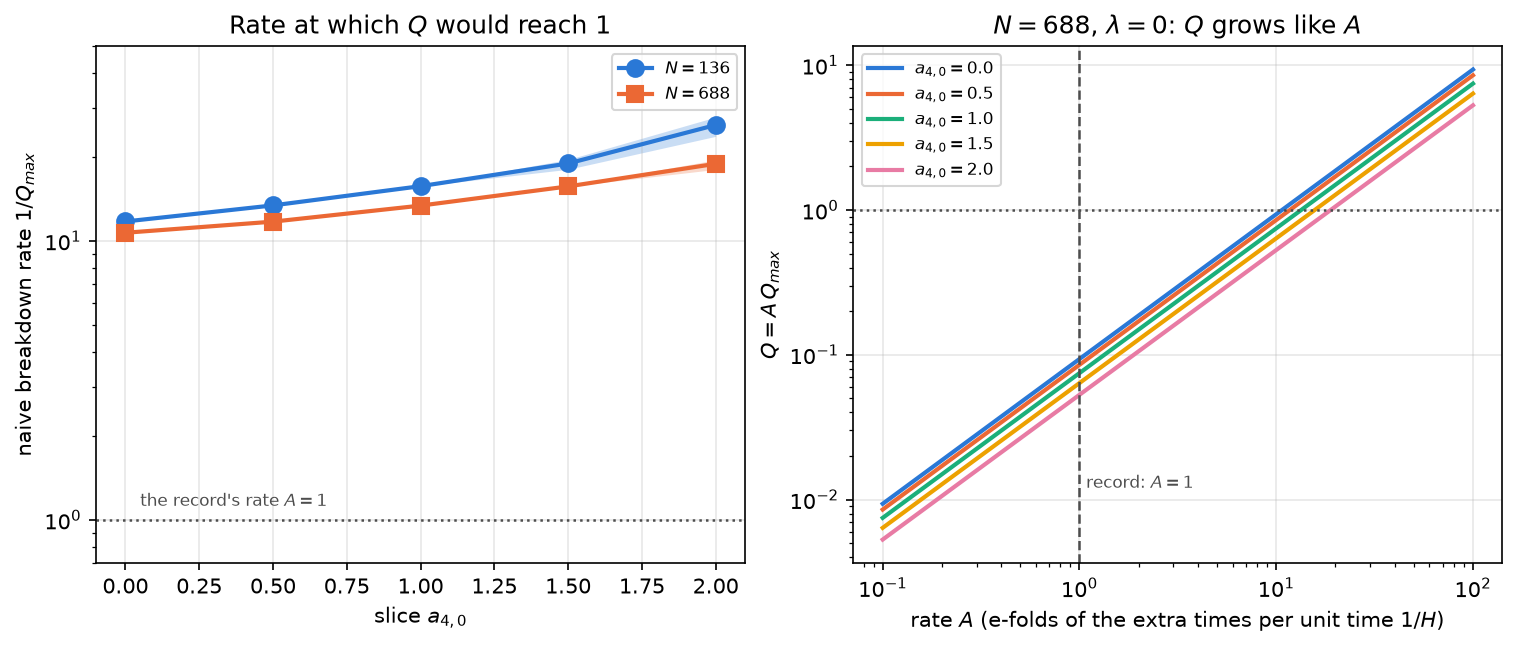

Figure 22a.1 saved as Revision/textbook/figures/22a_1_naive_rates.png
RESULT naive breakdown rate 1/Q_max of N688_lamm2_a00 = 10.7005
PASS every recorded state keeps Q below 1 up to the rate A = 10
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column Q_max


In [3]:
naive = {key: 1.0 / value for key, value in q_max.items() if value > 0.0}
weakest = min(naive, key=naive.get)  # the state that reaches Q = 1 first
rates = np.geomspace(0.1, 100.0, 200)  # rates A for the right panel
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2), layout="constrained")
for colour, marker, n in ((PALETTE[0], "o", 136), (PALETTE[1], "s", 688)):
    band = np.array([[naive[(n, tag, a4)] for a4 in SLICES] for tag in TAGS])
    left.fill_between(SLICES, band.min(axis=0), band.max(axis=0), color=colour,
                      alpha=0.25, lw=0)  # the spread over the five couplings
    left.plot(SLICES, band[0], "-", color=colour, marker=marker, ms=8, lw=2.0,
              label=f"$N = {n}$")
left.axhline(1.0, color="0.3", lw=1.2, ls=":")
left.text(0.05, 1.12, "the record's rate $A = 1$", fontsize=8, color="0.3")
left.set_yscale("log")
left.set_ylim(0.7, 50.0)
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("naive breakdown rate $1/Q_{max}$")
left.set_title("Rate at which $Q$ would reach 1")
left.legend(fontsize=8)
for colour, a4 in zip(PALETTE, SLICES):
    right.plot(rates, rates * q_max[(688, "lam0", a4)], color=colour, lw=2.0,
               label=f"$a_{{4,0}} = {a4}$")
right.axhline(1.0, color="0.3", lw=1.2, ls=":")
right.axvline(1.0, color="0.3", lw=1.2, ls="--")
right.text(1.08, 0.012, "record: $A = 1$", fontsize=8, color="0.3")
right.set_xscale("log")
right.set_yscale("log")
right.set_xlabel("rate $A$ (e-folds of the extra times per unit time $1/H$)")
right.set_ylabel("$Q = A\\,Q_{max}$")
right.set_title("$N = 688$, $\\lambda = 0$: $Q$ grows like $A$")
right.legend(fontsize=8)
save_figure(fig, "naive_rates",
            "Left: the naive breakdown rate $1/Q_{max}$ (vertical axis, logarithmic) "
            "of the ground states $N = 136$ (blue circles) and $N = 688$ (orange "
            "squares) against the slice $a_{4,0}$ (horizontal axis); the lines are "
            "the free states, the shaded bands the spread over the five couplings, "
            "the dotted line the record's rate $A = 1$. Right: $Q = A\\,Q_{max}$ "
            "against the rate $A$ for the free state $N = 688$ at the five slices "
            "(both axes logarithmic); $Q$ reaches 1 (dotted) only above $A = 10$. "
            "The naive estimate says the record's history is at least ten times "
            "too slow to break the instantaneous picture.")
report(f"naive breakdown rate 1/Q_max of {state_id(weakest[0], weakest[2], weakest[1])}",
       f"{naive[weakest]:.4f}")
check(naive[weakest] > 10.0,
      "every recorded state keeps Q below 1 up to the rate A = 10",
      record=f"{ADIABATIC}, column Q_max")

## 7. The solver's shooting method, vectorised

To go beyond the record we need the levels and orbitals ourselves. The next cell
reads the record's numerical parameters from `parameters.json` (the units, the tip
cutoff $L = 3$, the 900 RK4 steps) and defines five functions for the free block
($j = +1$, $M = 1$, $v = 0$, even brane parity):

- `shoot(eps, q)` integrates the block equation $a' = a - (q e^{-y} + \varepsilon)
  b$, $b' = (\varepsilon - q e^{-y})a - b$ (the real form of $h\varphi =
  \varepsilon\varphi$, ks-theory.json blockEquation.realForm) from the tip, where
  $b = 0$, to the brane with RK4, for whole arrays of energies and momenta at once,
  and follows the **Pruefer angle** $\theta = \mathrm{atan2}(b, a)$ continuously;
  the phase $\Phi = \theta(0)$ grows with $\varepsilon$, and the level with label
  $n$ is where $\Phi = n\pi$ (then $b(0) = 0$, the even brane condition);
- `levels(labels, q)` finds these levels by bisection to $10^{-13}$, the solver's
  root tolerance;
- `orbitals(eps, q)` returns the normalised orbitals on the fine grid of step ends
  and midpoints (midpoints by cubic Hermite interpolation, norm by Simpson's rule,
  as in the solver);
- `couplings(q, a, b)` returns the matrix of $\langle m|\partial_a h|n\rangle =
  -q\int e^{-y}(a_m a_n - b_m b_n)\,dy$ (line 8 of section 4);
- `per_unit_rate(eps, matrix)` returns $G_{nm} = |\langle n|\partial_a h|m\rangle|
  /(\varepsilon_n - \varepsilon_m)^2$, that is $Q/A$.

In [4]:
PARAMETERS = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                        .read_text(encoding="utf-8"))
L = PARAMETERS["physics"]["L_tipCutoff"]  # the tip cutoff y = -L
STEPS = PARAMETERS["numerics"]["rk4Steps"]  # RK4 steps from the tip to the brane
POINTS = 2 * STEPS + 1  # the fine grid: step ends and step midpoints
STEP = L / STEPS  # the length of one RK4 step in y
Y = -L * ((POINTS - 1 - np.arange(POINTS)) / (POINTS - 1))  # y from -L to 0
EW = np.exp(-Y)  # e^{-Hy} with H = 1, so kappa k = q e^{-y} with q = k e^{-a4,0}
SIMPSON = np.full(POINTS, 2.0 * STEP / 6.0)  # Simpson weights on the fine grid:
SIMPSON[1::2] = 4.0 * STEP / 6.0  # midpoints carry 4/6 of a step,
SIMPSON[0] = SIMPSON[-1] = STEP / 6.0  # the two ends 1/6
check(PARAMETERS["physics"]["H"] == 1.0 and PARAMETERS["physics"]["m"] == 1.0
      and L == 3.0 and STEPS == 900 and PARAMETERS["physics"]["dk"] == 0.25,
      "the record's units H = m = 1, tip cutoff L = 3, lattice step 0.25, 900 steps",
      record="Revision/kohn_sham/results/parameters.json, physics and numerics")


def shoot(eps, q, store=False):
    """Integrate the free block equation from the tip to the brane for the arrays
    eps (energies) and q (redshifted momenta) at once.  Returns the phase
    Phi = theta(0) and, if store is True, the list of (a, b) at the step ends."""
    a, b = np.ones_like(eps), np.zeros_like(eps)  # tip: b(-L) = 0, a(-L) = 1
    theta, raw = np.zeros_like(eps), np.zeros_like(eps)  # the angle, last atan2
    ends = [(a, b)] if store else None
    for i in range(STEPS):
        k0, k1, k2 = q * EW[2 * i], q * EW[2 * i + 1], q * EW[2 * i + 2]
        p1a, p1b = a - (k0 + eps) * b, (eps - k0) * a - b  # (a', b') at the start
        aa, bb = a + 0.5 * STEP * p1a, b + 0.5 * STEP * p1b
        p2a, p2b = aa - (k1 + eps) * bb, (eps - k1) * aa - bb  # at the midpoint
        aa, bb = a + 0.5 * STEP * p2a, b + 0.5 * STEP * p2b
        p3a, p3b = aa - (k1 + eps) * bb, (eps - k1) * aa - bb  # midpoint again
        aa, bb = a + STEP * p3a, b + STEP * p3b
        p4a, p4b = aa - (k2 + eps) * bb, (eps - k2) * aa - bb  # at the end
        a = a + STEP / 6.0 * (p1a + 2.0 * p2a + 2.0 * p3a + p4a)  # the RK4 step
        b = b + STEP / 6.0 * (p1b + 2.0 * p2b + 2.0 * p3b + p4b)
        new = np.arctan2(b, a)  # the angle of the point (a, b), in (-pi, pi]
        turn = new - raw  # how far the angle turned in this step, brought back
        turn = np.where(turn > np.pi, turn - 2.0 * np.pi, turn)  # into (-pi, pi]
        turn = np.where(turn <= -np.pi, turn + 2.0 * np.pi, turn)
        theta, raw = theta + turn, new  # the angle, followed continuously
        if store:
            ends.append((a, b))
    return theta, ends


def levels(labels, q):
    """The level with label n (Phi = n pi) for every pair (label, q): bisection on
    [-40, 40], halving the bracket until it is shorter than 1e-13."""
    target = np.pi * np.asarray(labels, dtype=float)
    q = np.asarray(q, dtype=float)
    low, high = np.full(q.shape, -40.0), np.full(q.shape, 40.0)
    while np.max(high - low) > 1e-13:  # 50 halvings of the length 80
        middle = 0.5 * (low + high)
        above = shoot(middle, q)[0] > target  # Phi grows with eps
        low, high = np.where(above, low, middle), np.where(above, middle, high)
    return 0.5 * (low + high)


def orbitals(eps, q):
    """The normalised orbitals (a, b) on the fine grid, one row per (eps, q)."""
    ends = shoot(eps, q, store=True)[1]
    a_e = np.array([pair[0] for pair in ends]).T  # rows: orbitals; columns: ends
    b_e = np.array([pair[1] for pair in ends]).T
    kap = q[:, None] * EW[None, 0::2]  # kappa k at the step ends
    da = a_e - (kap + eps[:, None]) * b_e  # the derivatives at the step ends
    db = (eps[:, None] - kap) * a_e - b_e
    a, b = np.zeros((len(eps), POINTS)), np.zeros((len(eps), POINTS))
    a[:, 0::2], b[:, 0::2] = a_e, b_e
    # cubic Hermite midpoint: (left + right)/2 + STEP (left' - right')/8
    a[:, 1::2] = 0.5 * (a_e[:, :-1] + a_e[:, 1:]) + STEP / 8.0 * (da[:, :-1] - da[:, 1:])
    b[:, 1::2] = 0.5 * (b_e[:, :-1] + b_e[:, 1:]) + STEP / 8.0 * (db[:, :-1] - db[:, 1:])
    norm = np.sqrt(np.sum(SIMPSON * (a * a + b * b), axis=1))  # Simpson's rule
    return a / norm[:, None], b / norm[:, None]


def couplings(q, a, b):
    """The matrix <m| d_a h |n> = -q int e^{-y} (a_m a_n - b_m b_n) dy of the
    orbitals (rows of a and b) of one sector at the redshifted momentum q."""
    weight = SIMPSON * EW  # Simpson weights times e^{-y}
    return -q * ((a * weight) @ a.T - (b * weight) @ b.T)


def per_unit_rate(eps, matrix):
    """G[n, m] = |<n| d_a h |m>| / (eps_n - eps_m)^2 = Q / A (0 for n = m)."""
    gap = eps[:, None] - eps[None, :]
    safe = np.where(gap == 0.0, 1.0, gap)  # 1 on the diagonal: no division by 0
    return np.where(gap == 0.0, 0.0, np.abs(matrix) / safe ** 2)

PASS the record's units H = m = 1, tip cutoff L = 3, lattice step 0.25, 900 steps
     reproduces Revision/kohn_sham/results/parameters.json, physics and numerics


## 8. The Fermi shells of the record, solved again

The record's largest $Q$ of the free states is always the jump from the band level
(label 0) to the first bulk level (label 1) in the Fermi shell: $n_2 = 4$
($k = 0.5$) for $N = 136$ and $n_2 = 11$ ($k = 0.829$) for $N = 688$. The next cell
solves the labels 0, 1, 2 of these sectors for the ten free states, **at the slice
0 with the redshifted momentum** $q = k e^{-a_{4,0}}$ (exact rule 2 of section 4),
compares the 30 levels with the record's level tables, and compares $Q$, the energy
difference and the matrix element with the record's columns `Q_max`,
`Q_max_delta_eps` and `Q_max_matrix_element`. Agreement at every slice is at the
same time a test of the rescaling identity.

In [5]:
LEVELS = "Revision/kohn_sham/results/ground/levels"
SHELL = {136: 4, 688: 11}  # the Fermi shell n2 of each N
fermi = [(n, a4) for n in (136, 688) for a4 in SLICES]  # the ten free states
q_fermi = np.array([0.25 * math.sqrt(SHELL[n]) * math.exp(-a4) for n, a4 in fermi])
eps_fermi = levels(np.tile([0, 1, 2], 10), np.repeat(q_fermi, 3)).reshape(10, 3)
worst_level, compared = 0.0, 0
for (n, a4), row in zip(fermi, eps_fermi):
    path = repository_file(f"{LEVELS}/{state_id(n, a4)}.csv")
    with open(path, newline="", encoding="utf-8") as handle:
        for entry in csv.DictReader(handle):
            sector = (int(entry["n2"]), int(entry["j"]), entry["parity"])
            if sector == (SHELL[n], 1, "even") and int(entry["label"]) <= 2:
                difference = float(entry["eps"]) - row[int(entry["label"])]
                worst_level = max(worst_level, abs(difference))
                compared += 1
a_f, b_f = orbitals(eps_fermi[:, :2].ravel(), np.repeat(q_fermi, 2))
worst_q, same_pair, q_free = 0.0, True, {}
say("   N  a4,0        q      eps_0      eps_1   Q (here)   Q_max (record)")
for i, (n, a4) in enumerate(fermi):
    matrix = couplings(q_fermi[i], a_f[2 * i:2 * i + 2], b_f[2 * i:2 * i + 2])
    gap = eps_fermi[i, 1] - eps_fermi[i, 0]
    q_free[(n, a4)] = abs(matrix[0, 1]) / gap ** 2  # Q at the rate A = 1
    row = record[state_id(n, a4)]
    for value, column in ((q_free[(n, a4)], "Q_max"), (gap, "Q_max_delta_eps"),
                          (abs(matrix[0, 1]), "Q_max_matrix_element")):
        worst_q = max(worst_q, abs(value / float(row[column]) - 1.0))
    pair = f"{SHELL[n]}:+1:even:0 -> {SHELL[n]}:+1:even:1"
    same_pair = same_pair and row["Q_max_pair"] == pair
    recorded = float(row["Q_max"])
    say(f"{n:4d}  {a4:4.1f}  {q_fermi[i]:7.4f}  {eps_fermi[i, 0]:9.6f}"
        f"  {eps_fermi[i, 1]:9.6f}  {q_free[(n, a4)]:.7f}  {recorded:.7f}")
report("levels compared with the record", compared)
report("largest |eps(here) - eps(record)|", f"{worst_level:.1e}")
report("largest relative difference of Q, delta eps, matrix element", f"{worst_q:.1e}")
check(compared == 30 and worst_level < 1e-12,
      "the 30 levels of the Fermi-shell sectors equal the record's within 1e-12",
      record=f"{LEVELS}/N136_lam0_a*.csv and N688_lam0_a*.csv, column eps")
check(worst_q < 1e-9,
      "Q_max, its energy difference and matrix element reproduced within 1e-9",
      record=f"{ADIABATIC}, columns Q_max, Q_max_delta_eps, Q_max_matrix_element; "
             "computed at the slice 0 with q = k e^(-a4,0), the rescaling identity "
             "of Revision/kohn_sham/reports/ks-rust-solver.json, check "
             "free_rescaling_relation_and_band_monotone")
check(same_pair,
      "the recorded pair is band level -> first bulk level of the Fermi shell",
      record=f"{ADIABATIC}, column Q_max_pair")

   N  a4,0        q      eps_0      eps_1   Q (here)   Q_max (record)
 136   0.0   0.5000   0.799646   2.852575  0.0851488  0.0851488
 136   0.5   0.3033   0.512555   2.400924  0.0745600  0.0745600
 136   1.0   0.1839   0.325768   2.071505  0.0636184  0.0636184
 136   1.5   0.1116   0.204636   1.820977  0.0527487  0.0527487
 136   2.0   0.0677   0.126766   1.651181  0.0383947  0.0383947
 688   0.0   0.8292   1.247113   3.500518  0.0934506  0.0934506
 688   0.5   0.5029   0.803752   2.858769  0.0852600  0.0852600
 688   1.0   0.3050   0.515229   2.405351  0.0746905  0.0746905
 688   1.5   0.1850   0.327505   2.074832  0.0637382  0.0637382
 688   2.0   0.1122   0.205760   1.823448  0.0528933  0.0528933
RESULT levels compared with the record = 30
RESULT largest |eps(here) - eps(record)| = 8.8e-14
RESULT largest relative difference of Q, delta eps, matrix element = 1.3e-13
PASS the 30 levels of the Fermi-shell sectors equal the record's within 1e-12
     reproduces Revision/kohn_sham/resul

## 9. One curve for every slice and every shell

By exact rule 2 the free $Q/A$ of a sector depends on one number only, the
redshifted momentum $q$. The next cell solves the labels $-3$ to $4$ of the sector
at 61 values of $q$ from $0.02$ to $6$ (equally spaced on a logarithmic scale),
computes the table $G_{nm}(q)$ of all jumps, and locates the largest value of the
band jump $G_{01}$ on a finer grid around the best grid point.

In [6]:
Q_GRID = np.geomspace(0.02, 6.0, 61)  # redshifted momenta q (units of m)
CURVE = np.arange(-3, 5)  # the labels -3 ... 4 of the sector
BAND = 3  # the position of label 0 in CURVE
q_rows = np.repeat(Q_GRID, len(CURVE))  # one row per (q, label)
curve_eps = levels(np.tile(CURVE, len(Q_GRID)), q_rows)
curve_a, curve_b = orbitals(curve_eps, q_rows)
curve_eps = curve_eps.reshape(len(Q_GRID), len(CURVE))
G = np.array([per_unit_rate(curve_eps[i], couplings(
    Q_GRID[i], curve_a[8 * i:8 * i + 8], curve_b[8 * i:8 * i + 8]))
    for i in range(len(Q_GRID))])  # G[i, n, m]: Q per unit rate at Q_GRID[i]
del curve_a, curve_b  # the orbitals are no longer needed
g01 = G[:, BAND, BAND + 1]  # band level -> first bulk level
top = int(np.argmax(g01))
fine_q = np.linspace(Q_GRID[top - 1], Q_GRID[top + 1], 41)  # around the top
fine_eps = levels(np.tile([0, 1], 41), np.repeat(fine_q, 2)).reshape(41, 2)
fine_a, fine_b = orbitals(fine_eps.ravel(), np.repeat(fine_q, 2))
fine_g = np.array([per_unit_rate(fine_eps[i], couplings(
    fine_q[i], fine_a[2 * i:2 * i + 2], fine_b[2 * i:2 * i + 2]))[0, 1]
    for i in range(41)])
g_star, q_star = float(fine_g.max()), float(fine_q[int(np.argmax(fine_g))])
report("largest Q per unit rate of the band jump, G*", f"{g_star:.5f}")
report("at the redshifted momentum q*", f"{q_star:.3f}")
report("naive breakdown rate of the band level, 0.02 <= q <= 6, 1/G*",
       f"{1.0 / g_star:.3f}")
report("largest G of the jumps band -> bulk 2, 3, 4 on the grid",
       ", ".join(f"{G[:, BAND, BAND + m].max():.5f}" for m in (2, 3, 4)))

RESULT largest Q per unit rate of the band jump, G* = 0.09979
RESULT at the redshifted momentum q* = 2.128
RESULT naive breakdown rate of the band level, 0.02 <= q <= 6, 1/G* = 10.021
RESULT largest G of the jumps band -> bulk 2, 3, 4 on the grid = 0.00640, 0.00249,
    0.00087


The next cell draws $G_{01}(q)$ and $G_{02}(q)$ and puts the record's $Q_{max}$ of
all 50 states with $Q_{max} > 0$ on the same axes, each at the $q = k e^{-a_{4,0}}$
of its Fermi shell. The free states fall exactly on the curve; the interacting ones
lie close to it. The grey band is the range of $q$ that the record covers. It also
checks that the top of the curve lies above every recorded value and below $0.1$,
and how much the interaction changes $Q_{max}$.

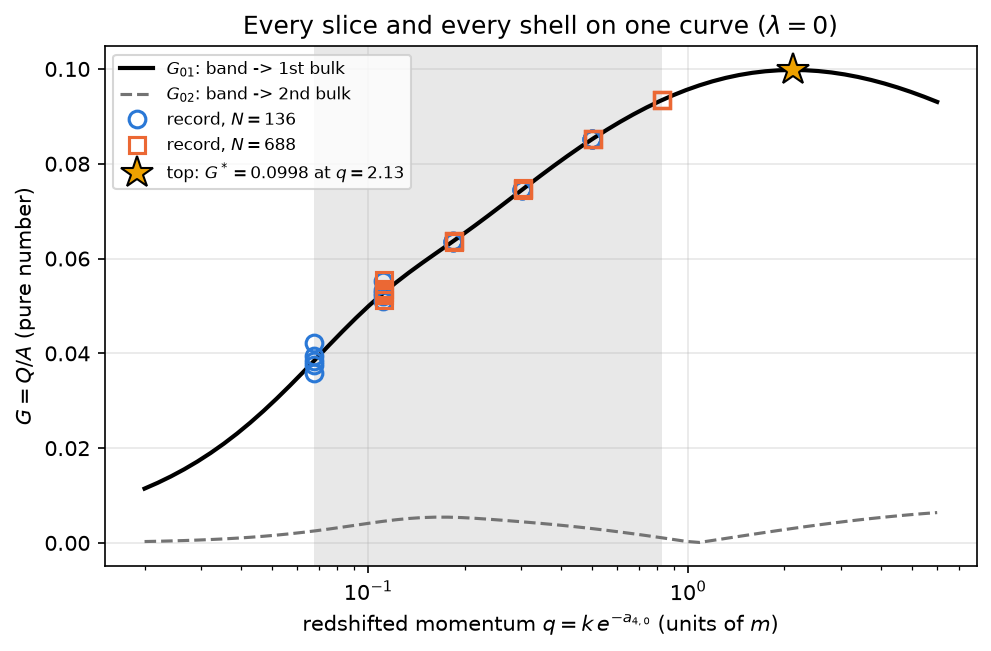

Figure 22a.2 saved as Revision/textbook/figures/22a_2_one_curve.png
RESULT largest relative change of Q_max by the interaction = 0.0980
PASS the top of the curve lies above every recorded Q_max and below 0.1
PASS the interaction changes Q_max by less than 15 percent
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column Q_max, all
    couplings


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(Q_GRID, g01, color="black", lw=2.0, label="$G_{01}$: band -> 1st bulk")
ax.plot(Q_GRID, G[:, BAND, BAND + 2], color="0.45", lw=1.5, ls="--",
        label="$G_{02}$: band -> 2nd bulk")
q_low, q_high = float(q_fermi.min()), float(q_fermi.max())
ax.axvspan(q_low, q_high, color="0.85", alpha=0.6, lw=0)  # the recorded range
for colour, marker, n in ((PALETTE[0], "o", 136), (PALETTE[1], "s", 688)):
    for tag in TAGS:
        xs = [0.25 * math.sqrt(SHELL[n]) * math.exp(-a4) for a4 in SLICES]
        ys = [q_max[(n, tag, a4)] for a4 in SLICES]
        ax.plot(xs, ys, marker, color=colour, ms=8, mfc="none", mew=1.5,
                label=f"record, $N = {n}$" if tag == "lam0" else None)
ax.plot([q_star], [g_star], "*", color=PALETTE[3], ms=16, mec="black",
        label=f"top: $G^* = {g_star:.4f}$ at $q = {q_star:.2f}$")
ax.set_xscale("log")
ax.set_xlabel("redshifted momentum $q = k\\,e^{-a_{4,0}}$ (units of $m$)")
ax.set_ylabel("$G = Q/A$ (pure number)")
ax.set_title("Every slice and every shell on one curve ($\\lambda = 0$)")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "one_curve",
            "The adiabaticity measure per unit rate, $G = Q/A$ (vertical axis, pure "
            "number), of the jump from the band level to the first (black) and "
            "second (grey, dashed) bulk level of a free sector, against the "
            "redshifted momentum $q = k e^{-a_{4,0}}$ (horizontal axis, "
            "logarithmic, units of $m$). Open symbols: the recorded $Q_{max}$ of "
            "the 50 states with $N = 136$ (circles) and $N = 688$ (squares), each "
            "at the $q$ of its Fermi shell; the five couplings overlap. The grey "
            "band is the range of the record; the star is the top of the curve, "
            "the largest $Q/A$ of the jump to the first bulk level for every "
            "shell and slice with $0.02 \\le q \\le 6$ (all states of the record).")
spread = max(abs(q_max[(n, tag, a4)] / q_max[(n, "lam0", a4)] - 1.0)
             for n in (136, 688) for tag in TAGS for a4 in SLICES)
report("largest relative change of Q_max by the interaction", f"{spread:.4f}")
check(largest < g_star < 0.1,
      "the top of the curve lies above every recorded Q_max and below 0.1")
check(spread < 0.15, "the interaction changes Q_max by less than 15 percent",
      record=f"{ADIABATIC}, column Q_max, all couplings")

## 10. Jumps across the gap into the negative branch

The record's $Q$ counts only jumps between levels of positive energy: its filling
convention treats the negative branch as the normal-ordered sea, which is not
populated. But the moving background couples the two branches too, through the
same matrix elements. In ordinary Dirac theory a jump from a filled negative level
to an empty positive one is the creation of a particle-antiparticle pair OF THE
FIELD, inside one universe; whether that reading holds in the 4+4 quantisation with
its Krein metric is OPEN, and it has nothing to do with the creation of universes.
The next cell draws, from the same table $G_{nm}(q)$, the jumps from the negative
levels $-1$ and $-2$ to the bulk levels and to the band level, next to the band
jump of section 9, and finds the largest jump from a negative to a positive bulk
level.

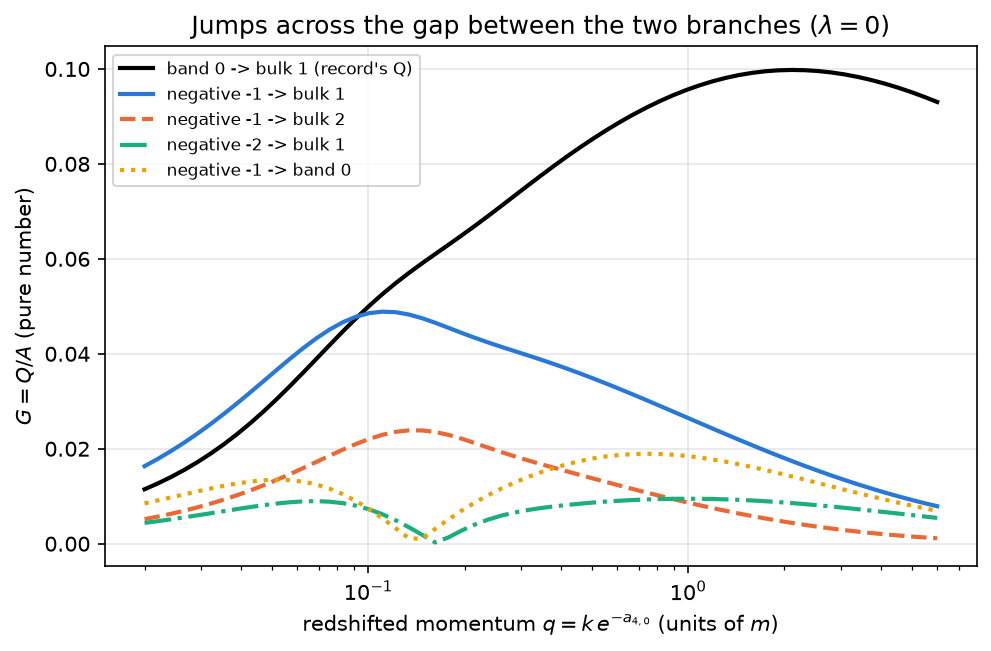

Figure 22a.3 saved as Revision/textbook/figures/22a_3_across_the_gap.png
RESULT largest G of a jump negative level -> bulk level = 0.04887
RESULT at the redshifted momentum = 0.1107
PASS every jump across the gap is weaker than half the top of the band jump


In [8]:
def g_pair(n, m):
    """G of the jump from label n to label m along Q_GRID."""
    return G[:, BAND + n, BAND + m]


sea = np.max([g_pair(n, m) for n in (-3, -2, -1) for m in (1, 2, 3, 4)], axis=0)
sea_top = int(np.argmax(sea))
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(Q_GRID, g01, color="black", lw=2.0, label="band 0 -> bulk 1 (record's Q)")
for colour, style, (n, m) in zip(PALETTE, ("-", "--", "-.", ":"),
                                 ((-1, 1), (-1, 2), (-2, 1), (-1, 0))):
    kind = "band" if m == 0 else "bulk"
    ax.plot(Q_GRID, g_pair(n, m), color=colour, lw=2.0, ls=style,
            label=f"negative {n} -> {kind} {m}")
ax.set_xscale("log")
ax.set_xlabel("redshifted momentum $q = k\\,e^{-a_{4,0}}$ (units of $m$)")
ax.set_ylabel("$G = Q/A$ (pure number)")
ax.set_title("Jumps across the gap between the two branches ($\\lambda = 0$)")
ax.legend(fontsize=8)
save_figure(fig, "across_the_gap",
            "The adiabaticity measure per unit rate $G = Q/A$ (vertical axis) of "
            "jumps from the negative levels $-1$ and $-2$ of a free sector to the "
            "bulk levels 1 and 2 and to the band level 0 (coloured), compared "
            "with the band jump of the record (black), against the redshifted "
            "momentum $q$ (horizontal axis, logarithmic, units of $m$). The jumps "
            "across the gap stay below 0.05 per unit rate; the strongest of them "
            "($-1 \\to$ bulk 1) peaks near $q = 0.11$ at 0.049 and exceeds the "
            "band jump only below $q$ of about 0.1; their reading as pair "
            "creation of the field is OPEN.")
report("largest G of a jump negative level -> bulk level", f"{sea[sea_top]:.5f}")
report("at the redshifted momentum", f"{Q_GRID[sea_top]:.4f}")
check(sea[sea_top] < 0.5 * g_star,
      "every jump across the gap is weaker than half the top of the band jump")

## 11. The Fermi-shell sector along the recorded span

For the time evolution we need the levels and the matrix $K_{mn}$ not at a few
slices but at every instant. The next cell takes the Fermi-shell sector of
$N = 688$ ($n_2 = 11$, $k = 0.829$, 96 particles in its band level), solves 20
labels ($-9$ to $10$) at 56 Chebyshev nodes of the span $a_{4,0} = 0$ to $2$, and
builds the interpolating Chebyshev polynomials of every level and every matrix
element: the coefficients are $c_k = (2/N)\sum_j f(s_j)\cos(k\theta_j)$, with $c_0$
halved. It then checks the interpolation against a direct solution at five other
points, and checks that the interpolated $Q$ at the five slices equals the
record's.

In [9]:
K11 = 0.25 * math.sqrt(11.0)  # the Fermi-shell momentum of N = 688 (units of m)
END = 2.0  # the recorded span of slices, a4,0 = 0 ... 2
NODES = 56  # Chebyshev nodes on the span
BASIS = np.arange(-9, 11)  # 20 labels: nine negative, the band level, ten bulk
SIZE, ZERO = len(BASIS), 9  # ZERO: the position of label 0 (the band level)
angles = np.pi * (np.arange(NODES) + 0.5) / NODES  # theta_j of the nodes
nodes_s = 0.5 * END * (1.0 + np.cos(angles))  # the nodes as slices a4,0
q_nodes = np.repeat(K11 * np.exp(-nodes_s), SIZE)  # one row per (node, label)
node_eps = levels(np.tile(BASIS, NODES), q_nodes)
node_a, node_b = orbitals(node_eps, q_nodes)
node_eps = node_eps.reshape(NODES, SIZE)
node_m = np.array([couplings(K11 * math.exp(-s), node_a[SIZE * i:SIZE * (i + 1)],
                             node_b[SIZE * i:SIZE * (i + 1)])
                   for i, s in enumerate(nodes_s)])
del node_a, node_b  # the orbitals are no longer needed


def chebyshev_coefficients(values):
    """c_k = (2/NODES) sum_j values_j cos(k theta_j), c_0 halved: the polynomial
    through the values at the nodes (one column per function)."""
    table = np.cos(np.outer(np.arange(NODES), angles))  # cos(k theta_j)
    coefficients = 2.0 / NODES * table @ values.reshape(NODES, -1)
    coefficients[0] *= 0.5
    return coefficients


FIT_EPS = chebyshev_coefficients(node_eps)  # 20 levels
FIT_M = chebyshev_coefficients(node_m)  # 400 matrix elements


def interpolated(s):
    """Levels (one row per point s) and coupling matrices from the fits."""
    x = 2.0 * np.asarray(s, dtype=float) / END - 1.0  # a4,0 = 0 ... 2 -> -1 ... 1
    eps = chebyshev.chebval(x, FIT_EPS).T
    matrix = chebyshev.chebval(x, FIT_M).T.reshape(len(x), SIZE, SIZE)
    return eps, matrix


test_s = np.array([0.03, 0.25, 0.77, 1.31, 1.97])  # five points between the nodes
test_q = np.repeat(K11 * np.exp(-test_s), SIZE)
test_eps = levels(np.tile(BASIS, 5), test_q)
test_a, test_b = orbitals(test_eps, test_q)
fit_eps, fit_m = interpolated(test_s)
error_eps = float(np.max(np.abs(fit_eps - test_eps.reshape(5, SIZE))))
error_m = max(float(np.max(np.abs(fit_m[i] - couplings(
    K11 * math.exp(-s), test_a[SIZE * i:SIZE * (i + 1)],
    test_b[SIZE * i:SIZE * (i + 1)])))) for i, s in enumerate(test_s))
slice_eps, slice_m = interpolated(SLICES)
slice_q = [abs(slice_m[i, ZERO, ZERO + 1]) / (slice_eps[i, ZERO + 1]
           - slice_eps[i, ZERO]) ** 2 for i in range(5)]
worst_slice = max(abs(slice_q[i] / q_max[(688, "lam0", a4)] - 1.0)
                  for i, a4 in enumerate(SLICES))
report("largest interpolation error of a level", f"{error_eps:.1e}")
report("largest interpolation error of a matrix element", f"{error_m:.1e}")
report("largest relative difference of the interpolated Q to the record",
       f"{worst_slice:.1e}")
check(error_eps < 1e-9 and error_m < 1e-7,
      "the Chebyshev fits reproduce levels within 1e-9 and couplings within 1e-7")
check(worst_slice < 1e-8, "the interpolated Q at the five slices equals the record's",
      record=f"{ADIABATIC}, column Q_max of N688_lam0_a00 ... a20")

RESULT largest interpolation error of a level = 7.3e-11
RESULT largest interpolation error of a matrix element = 6.4e-09
RESULT largest relative difference of the interpolated Q to the record = 1.4e-13
PASS the Chebyshev fits reproduce levels within 1e-9 and couplings within 1e-7
PASS the interpolated Q at the five slices equals the record's
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv, column Q_max of
    N688_lam0_a00 ... a20


The next cell draws the 20 levels of the sector along the span (left) and the
numbers $|K_{m0}|$ that drive the jumps out of the band level (right): $|K_{m0}|$ is
how far the band orbital turns towards level $m$ per e-fold of the extra times.

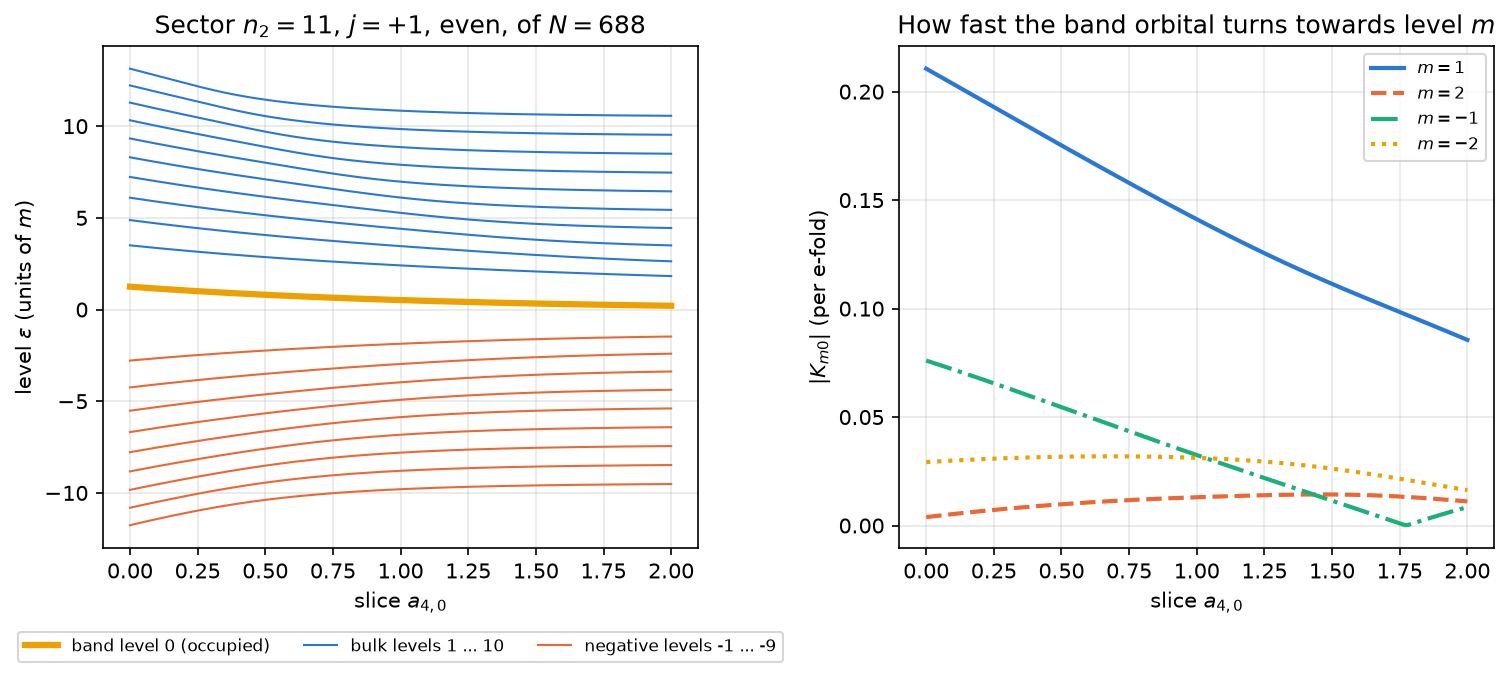

Figure 22a.4 saved as Revision/textbook/figures/22a_4_sector_levels.png


In [10]:
s_plot = np.linspace(0.0, END, 201)
eps_plot, m_plot = interpolated(s_plot)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.4), layout="constrained")
for i, label in enumerate(BASIS):
    if label == 0:
        left.plot(s_plot, eps_plot[:, i], color=PALETTE[3], lw=3.0,
                  label="band level 0 (occupied)")
    else:
        colour = PALETTE[0] if label > 0 else PALETTE[1]
        left.plot(s_plot, eps_plot[:, i], color=colour, lw=1.0)
left.plot([], [], color=PALETTE[0], lw=1.0, label="bulk levels 1 ... 10")
left.plot([], [], color=PALETTE[1], lw=1.0, label="negative levels -1 ... -9")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("level $\\varepsilon$ (units of $m$)")
left.set_title("Sector $n_2 = 11$, $j = +1$, even, of $N = 688$")
left.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
for colour, style, label in zip(PALETTE, ("-", "--", "-.", ":"), (1, 2, -1, -2)):
    m = ZERO + label
    turn = np.abs(m_plot[:, m, ZERO]) / np.abs(eps_plot[:, ZERO] - eps_plot[:, m])
    right.plot(s_plot, turn, color=colour, ls=style, lw=2.0, label=f"$m = {label}$")
right.set_xlabel("slice $a_{4,0}$")
right.set_ylabel("$|K_{m0}|$ (per e-fold)")
right.set_title("How fast the band orbital turns towards level $m$")
right.legend(fontsize=8)
save_figure(fig, "sector_levels",
            "Left: the 20 instantaneous levels (vertical axis, units of $m$) of the "
            "free Fermi-shell sector of $N = 688$ against the slice $a_{4,0}$ "
            "(horizontal axis): the occupied band level (thick) falls as the 3-"
            "momentum redshifts, the bulk levels above it and the negative levels "
            "below it move towards their values at $k = 0$. Right: $|K_{m0}|$, how "
            "far the band orbital turns towards level $m$ per e-fold (vertical "
            "axis), for $m = 1, 2, -1, -2$; all are below 0.25, so the band orbital "
            "changes slowly.")

## 12. The exact time evolution in the basis of instantaneous levels

Now we integrate line 5 of section 4, $\dot c_m = -i\varepsilon_m c_m - \dot a_4
\sum_n K_{mn}c_n$, in the basis of the 20 levels. We write the time as $x_4 = T u$
with $u$ running from 0 to 1, so that $dc/du = -iT\varepsilon c - (da_4/du)\,K c$;
$T$ is the duration of the passage. The next cell defines:

- `frame(s)`: the levels and the matrix $K_{mn} = \langle m|\partial_a h|n\rangle
  /(\varepsilon_n - \varepsilon_m)$ ($K_{nn} = 0$) at the slices $s$, from the
  Chebyshev fits;
- `passage(...)`: RK4 for $dc/du$ on a fine grid of 4000 steps of $u$ (it may use
  every second, fourth, ... point for fewer steps);
- `steps_needed(T)`: the smallest number of steps for which the fastest phase
  turns by at most 0.2 radian per step;
- the two histories: a **smooth passage** $a_4 = 2[u - \sin(2\pi u)/(2\pi)]$, whose
  rate $da_4/dx_4 = (4/T)\sin^2(\pi u)$ starts at zero, rises to its peak $A = 4/T$
  in the middle and falls back to zero; and the **constant rate** $a_4 = 2u$ of the
  record's kind, with $A = 2/T$.

In [11]:
U_STEPS = 4000  # the finest number of RK4 steps of one passage, u = 0 ... 1
U = np.linspace(0.0, 1.0, 2 * U_STEPS + 1)  # the fine grid: step ends, midpoints
CHOICES = [200, 400, 500, 1000, 2000, 4000]  # step numbers that divide U_STEPS
OFF = ~np.eye(SIZE, dtype=bool)  # every pair n != m
SPAN = float(np.ptp(node_eps))  # the largest energy difference of the basis


def frame(s):
    """Levels e[i, n] and the matrix k[i, m, n] = <m| d_a n> at the slices s[i]."""
    e, matrix = interpolated(s)
    gap = e[:, None, :] - e[:, :, None]  # gap[i, m, n] = eps_n - eps_m
    k = np.zeros_like(matrix)
    k[:, OFF] = matrix[:, OFF] / gap[:, OFF]  # line 6 of section 4; K_nn = 0
    return e, k


def steps_needed(duration):
    """The smallest step number of CHOICES with duration * SPAN / steps <= 0.2."""
    for steps in CHOICES:
        if duration * SPAN / steps <= 0.2:
            return steps
    return CHOICES[-1]


def passage(duration, e, k, rate, start, steps, keep=0):
    """RK4 for dc/du = -i duration e(u) c - rate(u) k(u) c from u = 0 to 1.
    e, k and rate are given on the fine grid U. Returns the final amplitudes and,
    if keep > 0, the list of the amplitudes after every keep steps."""
    stride = U_STEPS // steps  # fine-grid points per half step
    h = 1.0 / steps
    c = start.astype(complex)
    kept = [c]

    def slope(i, c):
        return -1j * duration * e[i] * c - rate[i] * (k[i] @ c)

    for step in range(steps):
        i = 2 * stride * step  # the start of this step on the fine grid
        s1 = slope(i, c)
        s2 = slope(i + stride, c + 0.5 * h * s1)
        s3 = slope(i + stride, c + 0.5 * h * s2)
        s4 = slope(i + 2 * stride, c + h * s3)
        c = c + h / 6.0 * (s1 + 2.0 * s2 + 2.0 * s3 + s4)
        if keep and (step + 1) % keep == 0:
            kept.append(c)
    return c, kept


S_SMOOTH = END * (U - np.sin(2.0 * np.pi * U) / (2.0 * np.pi))  # a4 along it
RATE_SMOOTH = 2.0 * END * np.sin(np.pi * U) ** 2  # its derivative d a4 / d u
E_SMOOTH, K_SMOOTH = frame(S_SMOOTH)
S_LINEAR = END * U  # the constant rate: a4 = END u
RATE_LINEAR = np.full_like(U, END)
E_LINEAR, K_LINEAR = frame(S_LINEAR)
START = np.zeros(SIZE, dtype=complex)
START[ZERO] = 1.0  # the particle starts in the band level
report("largest energy difference of the basis", f"{SPAN:.4f}", "m")

RESULT largest energy difference of the basis = 24.8912 m


## 13. A smooth passage at every rate

The smooth passage starts and ends with the rate zero, so there is no dressing at
the ends: whatever probability $P = 1 - |c_0|^2$ has left the band level at the end
is a real transition. The next cell runs the passage for 31 peak rates $A$ from
$0.25$ to $251$ (ten per factor 10), checks that the total probability stays 1,
computes the sudden limit twice (in the basis, with $T = 0$, and directly from the
overlap of the two band orbitals at $a_{4,0} = 0$ and $2$), and computes the
first-order estimate $P^{(1)} = \sum_m |d_m|^2$ with $d_m = -\int_0^1 (da_4/du)
K_{m0}\,e^{iT\int_0^u(\varepsilon_m - \varepsilon_0)\,du'}\,du$ (line 5 with $c_0 =
1$ on the right side, written for $d_m = c_m e^{iT\int\varepsilon_m du}$). Finally
it finds the rate $A_{1/2}$ at which $P$ reaches half the sudden value.

In [12]:
RATES = 10.0 ** np.linspace(-0.6, 2.4, 31)  # peak rates A from 0.25 to 251
excited, norm_error = [], 0.0
for rate in RATES:
    duration = 2.0 * END / rate  # T = 4/A: the peak rate is A
    c, _ = passage(duration, E_SMOOTH, K_SMOOTH, RATE_SMOOTH, START,
                   steps_needed(duration))
    excited.append(1.0 - abs(c[ZERO]) ** 2)  # probability to have left level 0
    norm_error = max(norm_error, abs(float(np.vdot(c, c).real) - 1.0))
excited = np.array(excited)
c, _ = passage(0.0, E_SMOOTH, K_SMOOTH, RATE_SMOOTH, START, 400)  # infinitely fast
sudden_basis = 1.0 - abs(c[ZERO]) ** 2
q_ends = np.array([K11, K11 * math.exp(-END)])  # the band level at a4,0 = 0 and 2
ends_a, ends_b = orbitals(levels([0, 0], q_ends), q_ends)
overlap = float(np.sum(SIMPSON * (ends_a[0] * ends_a[1] + ends_b[0] * ends_b[1])))
sudden = 1.0 - overlap ** 2  # the sudden limit from the two orbitals directly
du = 1.0 / (2 * U_STEPS)  # the spacing of the fine grid U
gaps = E_SMOOTH - E_SMOOTH[:, [ZERO]]  # eps_m - eps_0 along the passage
phase = np.vstack([np.zeros((1, SIZE)), np.cumsum(0.5 * (gaps[1:] + gaps[:-1]) * du,
                                                  axis=0)])  # trapezoid rule
weights = np.full(len(U), 2.0 * du / 3.0)  # Simpson weights on U
weights[1::2] = 4.0 * du / 3.0
weights[0] = weights[-1] = du / 3.0
drive = (weights * RATE_SMOOTH)[:, None] * K_SMOOTH[:, :, ZERO]  # da4/du K_m0
first = np.array([float(np.sum(np.abs(np.sum(drive * np.exp(
    1j * (2.0 * END / rate) * phase), axis=0)) ** 2)) for rate in RATES])
above = int(np.argmax(excited >= 0.5 * sudden))  # first rate past half the limit
x0, x1 = math.log(RATES[above - 1]), math.log(RATES[above])
y0, y1 = excited[above - 1] - 0.5 * sudden, excited[above] - 0.5 * sudden
rate_half = math.exp(x0 - y0 * (x1 - x0) / (y1 - y0))  # straight line in log A
report("largest |total probability - 1|", f"{norm_error:.1e}")
report("sudden limit: overlap / basis", f"{sudden:.6f} / {sudden_basis:.6f}")
report("P at A = 0.25, 1, 2.51, 251",
       ", ".join(f"{excited[i]:.3e}" for i in (0, 6, 10, 30)))
report("rate at which P reaches half the sudden limit, A_1/2", f"{rate_half:.3f}")
check(norm_error < 1e-9, "the evolution keeps the total probability 1 within 1e-9")
check(abs(sudden_basis / sudden - 1.0) < 1e-3,
      "the sudden limit of the 20-level basis equals the direct overlap within 0.1%")
check(abs(excited[-1] / sudden - 1.0) < 1e-3 and excited[0] < 1e-6
      and bool(np.all(excited <= sudden * (1.0 + 1e-3))),
      "P rises from below 1e-6 at A = 0.25 to the sudden limit at A = 251, never above")

RESULT largest |total probability - 1| = 1.2e-11
RESULT sudden limit: overlap / basis = 0.074906 / 0.074902
RESULT P at A = 0.25, 1, 2.51, 251 = 1.036e-07, 1.380e-02, 5.895e-02, 7.490e-02
RESULT rate at which P reaches half the sudden limit, A_1/2 = 1.508
PASS the evolution keeps the total probability 1 within 1e-9
PASS the sudden limit of the 20-level basis equals the direct overlap within 0.1%
PASS P rises from below 1e-6 at A = 0.25 to the sudden limit at A = 251, never above


The next cell draws $P$ against the peak rate $A$, with the first-order estimate,
the sudden limit and three rates: the record's $A = 1$, the exact $A_{1/2}$ and the
naive $1/Q_{max}$ of section 6.

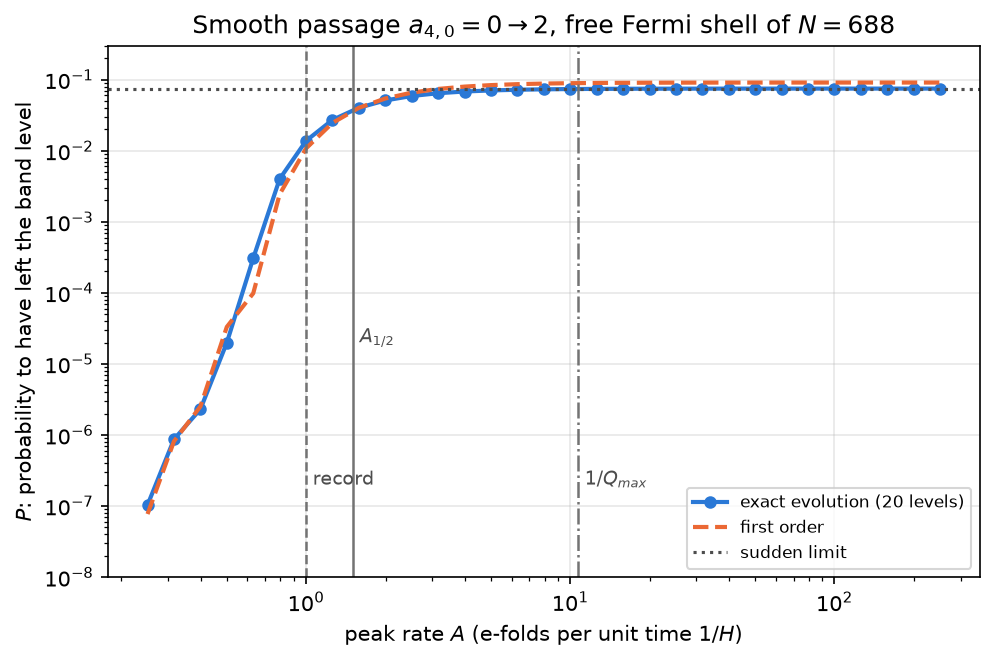

Figure 22a.5 saved as Revision/textbook/figures/22a_5_smooth_passage.png


In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(RATES, excited, "o-", color=PALETTE[0], ms=5, lw=2.0,
        label="exact evolution (20 levels)")
ax.plot(RATES, first, "--", color=PALETTE[1], lw=2.0, label="first order")
ax.axhline(sudden, color="0.3", ls=":", lw=1.5, label="sudden limit")
for value, style, text, height in ((1.0, "--", "record", 2e-7),
                                   (rate_half, "-", "$A_{1/2}$", 2e-5),
                                   (naive[weakest], "-.", "$1/Q_{max}$", 2e-7)):
    ax.axvline(value, color="0.45", ls=style, lw=1.2)
    ax.text(value * 1.06, height, text, fontsize=9, color="0.3")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-8, 0.3)
ax.set_xlabel("peak rate $A$ (e-folds per unit time $1/H$)")
ax.set_ylabel("$P$: probability to have left the band level")
ax.set_title("Smooth passage $a_{4,0} = 0 \\to 2$, free Fermi shell of $N = 688$")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "smooth_passage",
            "The probability $P$ that the particle of the band level has left it "
            "at the end of a smooth passage from $a_{4,0} = 0$ to $2$ (vertical "
            "axis, logarithmic), against the peak rate $A$ (horizontal axis, "
            "logarithmic): exact evolution in the basis of 20 instantaneous levels "
            "(blue), the first-order estimate (orange, dashed) and the sudden limit "
            "(dotted). Vertical lines: the record's rate $A = 1$, the rate "
            "$A_{1/2}$ at which $P$ reaches half the sudden limit, and the naive "
            "breakdown rate $1/Q_{max}$. The gas stops following its level near "
            "$A = 1$, about seven times below the naive estimate ($A_{1/2} = 1.5$ "
            "against $1/Q_{max} = 10.7$), but $P$ never exceeds the sudden limit "
            "of about 7.5 percent.")

## 14. A constant rate: the dressing that Q measures

Section 4 showed that at a constant rate the particle carries the dressing
$\alpha_m = iAK_{m0}/(\varepsilon_m - \varepsilon_0)$, of total probability
$\sum_m Q_{0m}^2$. The next cell tests this with the exact evolution at the
constant rates $A = 0.3$, $1$ and $3$ over the span $a_{4,0} = 0$ to $2$: it starts
in the dressed state (level 0 plus the admixtures $\alpha_m$, normalised) and
compares the exact $P(a_4)$ with $\sum_m Q_{0m}(a_4)^2$ at 101 points. At $A = 1$
it also starts in the bare level 0, to show the extra transition caused by
switching the motion on abruptly.

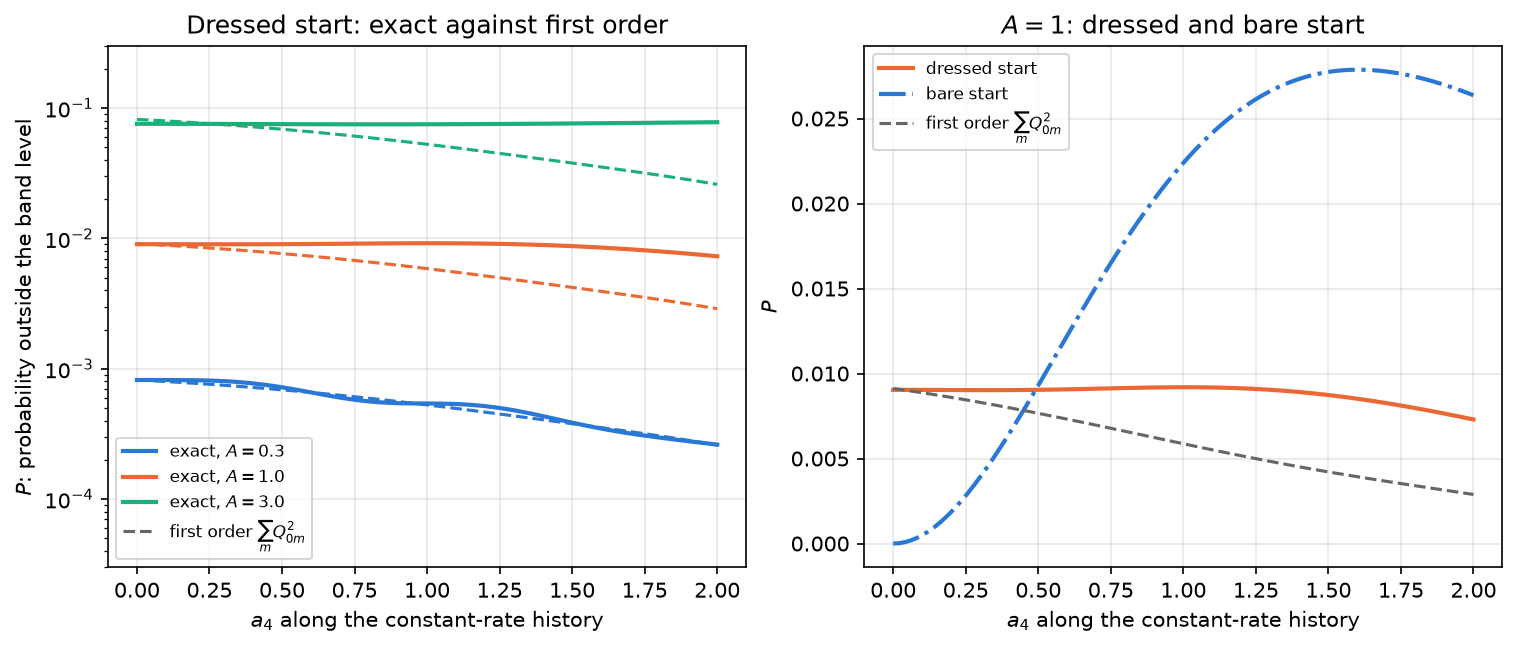

Figure 22a.6 saved as Revision/textbook/figures/22a_6_constant_rate.png
RESULT A = 0.3: largest relative difference exact / first order = 0.113
RESULT A = 1: exact P at a4 = 0 and 2 = 0.00904, 0.00730
RESULT A = 1: first-order dressing at a4 = 0 and 2 = 0.00912, 0.00289
RESULT A = 1, bare start: largest P = 0.02787
PASS at A = 0.3 the exact P agrees with the first-order dressing within 15 percent at all
    101 points


In [14]:
MARKS = np.arange(0, 2 * U_STEPS + 1, 2 * U_STEPS // 100)  # 101 points of U


def dressed(rate):
    """Level 0 with the first-order admixtures i A K_m0 / (eps_m - eps_0)."""
    e, k = E_LINEAR[0], K_LINEAR[0]
    c = START.copy()
    for m in range(SIZE):
        if m != ZERO:
            c[m] = 1j * rate * k[m, ZERO] / (e[m] - e[ZERO])
    return c / np.linalg.norm(c)


def dressing(rate):
    """The first-order estimate sum_m Q_0m^2 at the 101 marks."""
    e, k = E_LINEAR[MARKS], K_LINEAR[MARKS]
    total = np.zeros(len(MARKS))
    for m in range(SIZE):
        if m != ZERO:  # Q_0m = A |K_m0| / |eps_m - eps_0|
            total += (rate * k[:, m, ZERO] / (e[:, m] - e[:, ZERO])) ** 2
    return total


runs = {}
for rate in (0.3, 1.0, 3.0):
    duration = END / rate  # T = 2/A for the constant rate A
    steps = steps_needed(duration)
    _, kept = passage(duration, E_LINEAR, K_LINEAR, RATE_LINEAR, dressed(rate),
                      steps, keep=steps // 100)
    runs[rate] = np.array([1.0 - abs(c[ZERO]) ** 2 for c in kept])
steps = steps_needed(END)
_, kept = passage(END, E_LINEAR, K_LINEAR, RATE_LINEAR, START, steps, keep=steps // 100)
bare = np.array([1.0 - abs(c[ZERO]) ** 2 for c in kept])
s_marks = S_LINEAR[MARKS]
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2), layout="constrained")
for colour, rate in zip(PALETTE, (0.3, 1.0, 3.0)):
    left.plot(s_marks, runs[rate], color=colour, lw=2.0, label=f"exact, $A = {rate}$")
    left.plot(s_marks, dressing(rate), color=colour, lw=1.5, ls="--")
left.plot([], [], color="0.4", ls="--", label="first order $\\sum_m Q_{0m}^2$")
left.set_yscale("log")
left.set_ylim(3e-5, 0.3)
left.set_xlabel("$a_4$ along the constant-rate history")
left.set_ylabel("$P$: probability outside the band level")
left.set_title("Dressed start: exact against first order")
left.legend(fontsize=8, loc="lower left")
right.plot(s_marks, runs[1.0], color=PALETTE[1], lw=2.0, label="dressed start")
right.plot(s_marks, bare, color=PALETTE[0], lw=2.0, ls="-.", label="bare start")
right.plot(s_marks, dressing(1.0), color="0.4", lw=1.5, ls="--",
           label="first order $\\sum_m Q_{0m}^2$")
right.set_xlabel("$a_4$ along the constant-rate history")
right.set_ylabel("$P$")
right.set_title("$A = 1$: dressed and bare start")
right.legend(fontsize=8)
save_figure(fig, "constant_rate",
            "Left: the probability $P$ that the particle is not in its "
            "instantaneous band level (vertical axis, logarithmic) along a history "
            "of constant rate $A = 0.3$, $1$, $3$ from $a_4 = 0$ to $2$ "
            "(horizontal axis), exact (solid) and the first-order dressing "
            "$\\sum_m Q_{0m}^2$ (dashed), starting in the dressed state. At $A = "
            "0.3$ they agree; at $A = 1$ the exact $P$ stays near 0.009 while the "
            "estimate falls; at $A = 3$ first order fails. Right: $A = 1$ with the "
            "dressed start and with the bare start (an abrupt start of the motion), "
            "which leaves about three times more.")
deviation = float(np.max(np.abs(runs[0.3] / dressing(0.3) - 1.0)))
report("A = 0.3: largest relative difference exact / first order", f"{deviation:.3f}")
report("A = 1: exact P at a4 = 0 and 2", f"{runs[1.0][0]:.5f}, {runs[1.0][-1]:.5f}")
report("A = 1: first-order dressing at a4 = 0 and 2",
       f"{dressing(1.0)[0]:.5f}, {dressing(1.0)[-1]:.5f}")
report("A = 1, bare start: largest P", f"{bare.max():.5f}")
check(deviation < 0.15, "at A = 0.3 the exact P agrees with the first-order dressing "
      "within 15 percent at all 101 points")

## 15. How far the sudden limit reaches, and how many levels are needed

The sudden limit caps the damage, and it depends on how much the band orbital
itself changes. The next cell computes the band orbital at the end slices $a_{4,0}
= 0, 0.1, ..., 6$ (beyond the record's span; free field, computed here) and the
sudden limit $1 - |\int\varphi_0(a_{4,0})^\dagger\varphi_0(0)\,dy|^2$ against the end
slice, and draws a few of the orbitals.

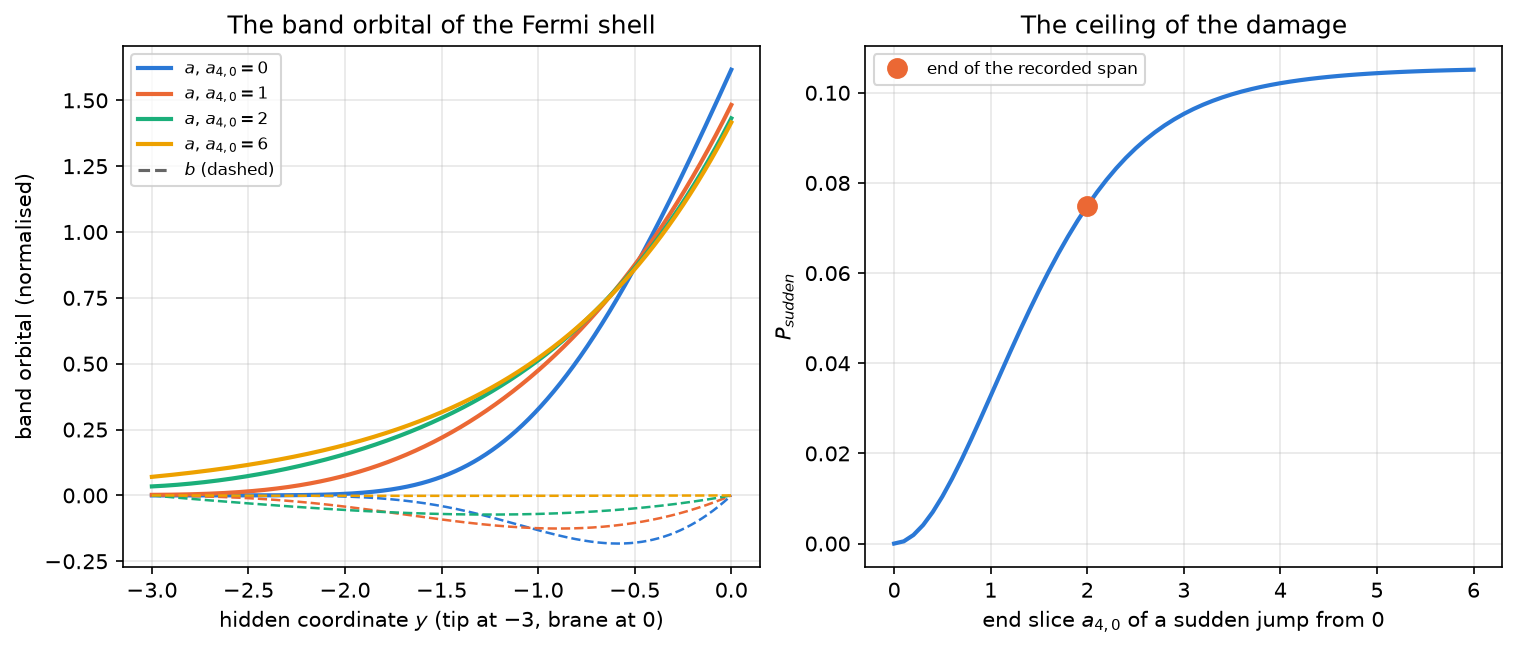

Figure 22a.7 saved as Revision/textbook/figures/22a_7_sudden_ceiling.png
RESULT sudden limit for the end slices 2, 4, 6 = 0.0749, 0.1021, 0.1051
PASS the sudden limit grows with the end slice and stays below 0.11 up to 6


In [15]:
ENDS = np.linspace(0.0, 6.0, 61)  # end slices of a sudden jump from a4,0 = 0
ends_q = K11 * np.exp(-ENDS)
band_a, band_b = orbitals(levels(np.zeros(61), ends_q), ends_q)
ceiling = 1.0 - (band_a @ (SIMPSON * band_a[0]) + band_b @ (SIMPSON * band_b[0])) ** 2
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2), layout="constrained")
for colour, index in zip(PALETTE, (0, 10, 20, 60)):
    left.plot(Y, band_a[index], color=colour, lw=2.0,
              label=f"$a$, $a_{{4,0}} = {ENDS[index]:.0f}$")
    left.plot(Y, band_b[index], color=colour, lw=1.2, ls="--")
left.plot([], [], color="0.4", ls="--", label="$b$ (dashed)")
left.set_xlabel("hidden coordinate $y$ (tip at $-3$, brane at 0)")
left.set_ylabel("band orbital (normalised)")
left.set_title("The band orbital of the Fermi shell")
left.legend(fontsize=8)
right.plot(ENDS, ceiling, color=PALETTE[0], lw=2.0)
right.plot([END], [sudden], "o", color=PALETTE[1], ms=9,
           label="end of the recorded span")
right.set_xlabel("end slice $a_{4,0}$ of a sudden jump from 0")
right.set_ylabel("$P_{sudden}$")
right.set_title("The ceiling of the damage")
right.legend(fontsize=8)
save_figure(fig, "sudden_ceiling",
            "Left: the band orbital of the Fermi shell of $N = 688$, components "
            "$a$ (solid) and $b$ (dashed), against the hidden coordinate $y$ "
            "(horizontal axis) at the slices $a_{4,0} = 0$, $1$, $2$, $6$: as the "
            "momentum redshifts, $b$ shrinks and the orbital approaches the brane "
            "zero mode $e^{y}$. Right: the sudden limit $P_{sudden}$ (vertical "
            "axis) of a jump from $a_{4,0} = 0$ to the end slice (horizontal "
            "axis); it grows and levels off near 0.105: even an instant jump to "
            "the far future leaves almost 90 percent of the particles in the band "
            "level.")
report("sudden limit for the end slices 2, 4, 6",
       ", ".join(f"{ceiling[i]:.4f}" for i in (20, 40, 60)))
check(np.all(np.diff(ceiling) > -1e-12) and ceiling[-1] < 0.11
      and abs(ceiling[20] - sudden) < 1e-12,
      "the sudden limit grows with the end slice and stays below 0.11 up to 6")

The last numerical question is how good the truncated basis and the time steps
are. The next cell repeats the sudden limit and the smooth passages at $A = 1$ and
$A = 3$ with smaller bases (the labels $-l ... l$ and $-l ... l + 1$, from 3 to 20
levels), draws the differences to the reference (the direct overlap for the sudden
limit, the 20-level result for $A = 1$ and $3$), and repeats three passages with
twice or half the number of steps.

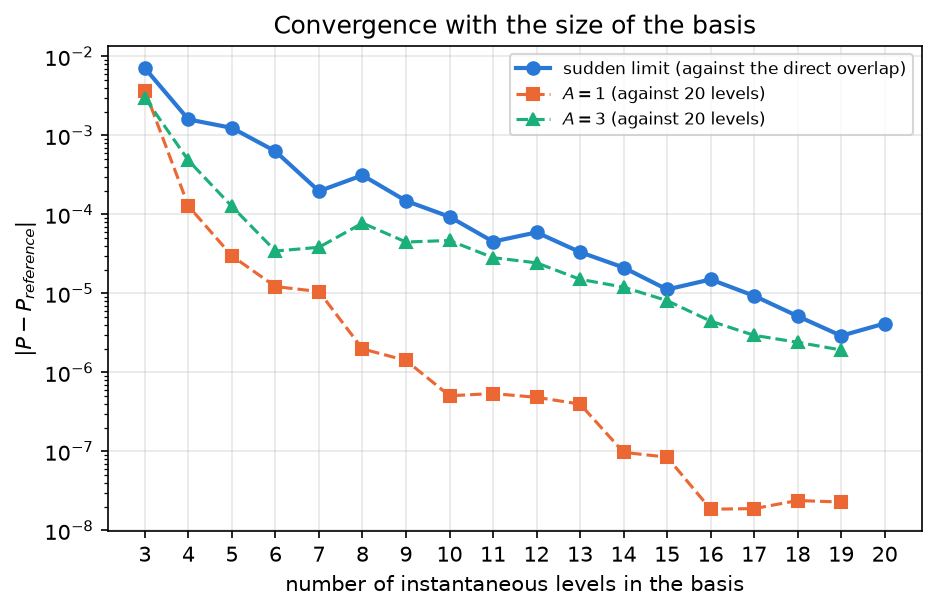

Figure 22a.8 saved as Revision/textbook/figures/22a_8_convergence.png
RESULT sudden limit: error with 20 levels = 4.2e-06
RESULT A = 1: change from 18 to 20 levels = 2.4e-08
RESULT largest change of P when the steps are doubled or halved = 3.0e-11
PASS the 20-level basis is converged: sudden limit within 1e-5, A = 1 within 1e-6
PASS doubling or halving the time steps changes P by less than 1e-9


In [16]:
sizes, errors = [], {"sudden": [], 1.0: [], 3.0: []}
results = {}
for low in range(1, 10):
    for high in (low, low + 1):
        chosen = np.where((BASIS >= -low) & (BASIS <= high))[0]
        zero = int(np.where(BASIS[chosen] == 0)[0][0])
        e, k = E_SMOOTH[:, chosen], K_SMOOTH[:, chosen][:, :, chosen]
        start = np.zeros(len(chosen), dtype=complex)
        start[zero] = 1.0
        sizes.append(len(chosen))
        c, _ = passage(0.0, e, k, RATE_SMOOTH, start, 400)
        errors["sudden"].append(abs(1.0 - abs(c[zero]) ** 2 - sudden))
        for rate in (1.0, 3.0):
            duration = 2.0 * END / rate
            c, _ = passage(duration, e, k, RATE_SMOOTH, start, steps_needed(duration))
            results[(len(chosen), rate)] = 1.0 - abs(c[zero]) ** 2
for rate in (1.0, 3.0):
    errors[rate] = [abs(results[(size, rate)] - results[(SIZE, rate)])
                    for size in sizes]
halving = 0.0
for rate in (RATES[0], 1.0, 10.0):
    duration = 2.0 * END / rate
    steps = steps_needed(duration)
    other = 2 * steps if steps < U_STEPS else steps // 2
    p_one, p_two = (1.0 - abs(passage(duration, E_SMOOTH, K_SMOOTH, RATE_SMOOTH, START,
                                      n)[0][ZERO]) ** 2 for n in (steps, other))
    halving = max(halving, abs(p_one - p_two))
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(sizes, errors["sudden"], "o-", color=PALETTE[0], lw=2.0, ms=6,
        label="sudden limit (against the direct overlap)")
for colour, marker, rate in ((PALETTE[1], "s", 1.0), (PALETTE[2], "^", 3.0)):
    ax.plot(sizes[:-1], errors[rate][:-1], marker + "--", color=colour, lw=1.5, ms=6,
            label=f"$A = {rate:.0f}$ (against 20 levels)")
ax.set_yscale("log")
ax.set_xticks(range(3, 21))
ax.set_xlabel("number of instantaneous levels in the basis")
ax.set_ylabel("$|P - P_{reference}|$")
ax.set_title("Convergence with the size of the basis")
ax.legend(fontsize=8)
save_figure(fig, "convergence",
            "The error of the probability $P$ (vertical axis, logarithmic) against "
            "the number of instantaneous levels kept in the basis (horizontal "
            "axis), for the sudden limit (blue, against the direct overlap of the "
            "two orbitals) and for the smooth passages at $A = 1$ and $A = 3$ "
            "(against the 20-level result). The errors fall steadily; with 20 "
            "levels the sudden limit is right to a few millionths.")
report("sudden limit: error with 20 levels", f"{errors["sudden"][-1]:.1e}")
report("A = 1: change from 18 to 20 levels", f"{errors[1.0][-3]:.1e}")
report("largest change of P when the steps are doubled or halved", f"{halving:.1e}")
check(errors["sudden"][-1] < 1e-5 and errors[1.0][-3] < 1e-6,
      "the 20-level basis is converged: sudden limit within 1e-5, A = 1 within 1e-6")
check(halving < 1e-9, "doubling or halving the time steps changes P by less than 1e-9")

## 16. The breakdown estimate

The last cell collects the four estimates of the rate at which the instantaneous
picture breaks down, for the free Fermi-shell sector of $N = 688$ over the recorded
span, prints the probability that a particle is not in its instantaneous level at
the record's rate, checks that every figure file exists, and prints the number of
checks that passed.

In [17]:
q_first = q_max[(688, "lam0", 0.0)]  # the largest Q of the free Fermi shell, A = 1
estimates = [
    ("naive: Q = 1 for the weakest recorded state", naive[weakest]),
    ("naive: Q = 1 for the band level, 0.02 <= q <= 6", 1.0 / g_star),
    ("first order: Q^2 reaches the sudden limit", math.sqrt(sudden) / q_first),
    ("exact: P reaches half the sudden limit", rate_half),
]
say("breakdown estimate                                    rate A")
for label, value in estimates:
    say(f"{label:50s} {value:9.3f}")
report("P at the record's rate A = 1, constant rate (dressed start)",
       f"{runs[1.0].min():.4f} ... {runs[1.0].max():.4f}")
report("P at the peak rate A = 1, smooth passage", f"{excited[6]:.4f}")
report("sudden limit over the span 0 ... 2, the most P reaches in the scan",
       f"{sudden:.4f}")
NAMES = ["naive_rates", "one_curve", "across_the_gap", "sector_levels",
         "smooth_passage", "constant_rate", "sudden_ceiling", "convergence"]
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/22a_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

breakdown estimate                                    rate A
naive: Q = 1 for the weakest recorded state           10.701
naive: Q = 1 for the band level, 0.02 <= q <= 6       10.021
first order: Q^2 reaches the sudden limit              2.929
exact: P reaches half the sudden limit                 1.508
RESULT P at the record's rate A = 1, constant rate (dressed start) = 0.0073 ... 0.0092
RESULT P at the peak rate A = 1, smooth passage = 0.0138
RESULT sudden limit over the span 0 ... 2, the most P reaches in the scan = 0.0749
PASS every figure file of this notebook exists
ALL 20 CHECKS PASSED (notebook 22a)


## 17. What this notebook showed

- The record's adiabaticity measure $Q$ is, in this notebook's reading (the record
  calls $Q^2$ the leading-order transition probability), the first-order amplitude
  of the dressing that a moving particle carries; by an exact argument it grows in
  proportion to the rate $A$ of the history. At the record's rate $A = 1$,
  $Q_{max} \le 0.0935$ for all 75 states (COMPUTED, Revision record), so the naive
  breakdown "$Q = 1$" would need $A \ge 10.7$.
- The solver's shooting method, written again in vectorised Python, reproduces the
  record's levels and $Q$ of the free Fermi shells; with the exact rescaling
  identity every slice and every shell falls on ONE curve $Q/A = G(q)$, whose top
  is $G^* = 0.0998$ at $q = 2.13$ (COMPUTED here): for a particle in the band level
  of every shell and slice with $0.02 \le q \le 6$ (all states of the record) the
  naive breakdown rate is at least $A = 10.0$.
- Jumps across the gap into the negative branch, which the record leaves out, are
  weaker than the top of the band jump (below 0.05 per unit rate; the strongest,
  $-1 \to$ bulk 1, peaks near $q = 0.11$) but stronger than the band jump itself
  below $q$ of about 0.1; their reading as pair creation of the field in 4+4
  dimensions is OPEN, and they say nothing about the creation of universes.
- The exact evolution of the free Fermi-shell sector of $N = 688$ (20-level basis,
  converged to a few millionths) tells a sharper story: the gas stops following its
  instantaneous level already near $A = 1$ ($A_{1/2} \approx 1.5$ for a smooth
  passage), about seven times below the naive estimate ($1/Q_{max} = 10.7$); but
  the damage is capped by the sudden limit, 7.5 percent over the recorded span and
  about 10.5 percent even for an instant jump to $a_{4,0} = 6$, because the band
  orbital itself changes slowly.
  At the record's rate the probability to find a Fermi-shell particle outside its
  instantaneous level is about 1 percent (COMPUTED here).
- What remains OPEN: the self-consistent time-dependent Kohn-Sham problem with
  interaction, the meaning of the negative branch, the history itself (a PRESCRIBED
  BACKGROUND, without back-reaction) and the ASSUMED Z2 brane. A student could
  attack the first by starting from the record's self-consistent states and
  recomputing the potentials $M$ and $v$ at every time step from the evolving
  orbitals of all occupied sectors (time-dependent Kohn-Sham theory), then
  repeating sections 13 and 14 with them.